In [1]:
import numpy as np
def mahalanobis_distance(m1, m2, B):
    """
    m1, m2: средние векторы
    B: ковариационная матрица (общая для обоих распределений)
    """
    m1 = np.asarray(m1)
    m2 = np.asarray(m2)
    B = np.asarray(B)
    
    diff = m1 - m2
    inv_B = np.linalg.inv(B)
    
    return diff.T @ inv_B @ diff

# Байесовская разделяющая граница для двумерных нормальных векторов (Равные ковариации)

Для двух классов $ \Omega_0 \ $ и $ \Omega_1\ $ с равными ковариационными матрицами \(B\) дискриминантные функции имеют вид:

$$
d_0(x) = x^T B^{-1} M_0 - \frac{1}{2} M_0^T B^{-1} M_0
$$

$$
d_1(x) = x^T B^{-1} M_1 - \frac{1}{2} M_1^T B^{-1} M_1
$$

Байесовская граница определяется условием равенства дискриминантов:

$$
d_0(x) = d_1(x)
$$

Подставляем выражения:

$$
x^T B^{-1} M_0 - \frac{1}{2} M_0^T B^{-1} M_0 = x^T B^{-1} M_1 - \frac{1}{2} M_1^T B^{-1} M_1
$$

Переносим все в левую часть:

$$
x^T B^{-1} (M_0 - M_1) - \frac{1}{2} \left( M_0^T B^{-1} M_0 - M_1^T B^{-1} M_1 \right) = 0
$$

Определяем коэффициенты:

$$
w = B^{-1} (M_0 - M_1), \quad w_0 = -\frac{1}{2} \left( M_0^T B^{-1} M_0 - M_1^T B^{-1} M_1 \right)
$$

Тогда уравнение границы имеет линейный вид:

$$
x^T w + w_0 = 0
$$

Для двумерного случая граница выражается как прямая:

$$
y = -\frac{w[0]}{w[1]} x - \frac{w_0}{w[1]}
$$

Mahalanobis distance: 12.5
P(1|0) = 0.03854993587177085
P(0|1) = 0.03854993587177085
Total error = 0.03854993587177085


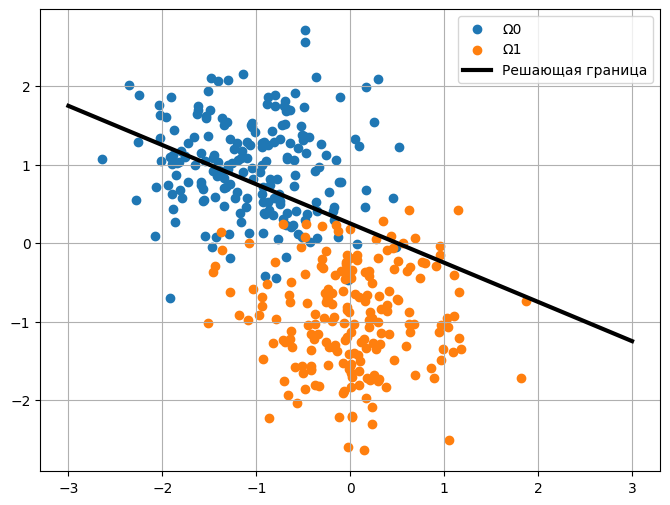

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import norm

X0 = np.load('distrib_w0_[-1,1].npy')
X1 = np.load('distrib_w1_[0,-1].npy')

M0 = np.array([1,1])
M1 = np.array([0,-1])

B = np.array([[0.4,0],
              [0,0.4]])

invB = np.linalg.inv(B)
diff = M1 - M0 
w = invB @  diff 
w0 = -0.5 * (M1.T @ invB @ M1 - M0.T @ invB @ M0)

x = np.linspace(-3,3,200)
y = -(w[0]*x + w0)/w[1]

mah_D = mahalanobis_distance(M0, M1, B)
print("Mahalanobis distance:", mah_D)

P10 = norm.cdf(-np.sqrt(mah_D)/2)
P01 = P10

Pe = 0.5*(P10 + P01)

print("P(1|0) =", P10)
print("P(0|1) =", P01)
print("Total error =", Pe)

plt.figure(figsize=(8,6))

plt.scatter(X0[:,0], X0[:,1], label='Ω0')
plt.scatter(X1[:,0], X1[:,1], label='Ω1')

plt.plot(x,y,'k',linewidth=3,label='Решающая граница')

plt.legend()
plt.grid()
plt.show()

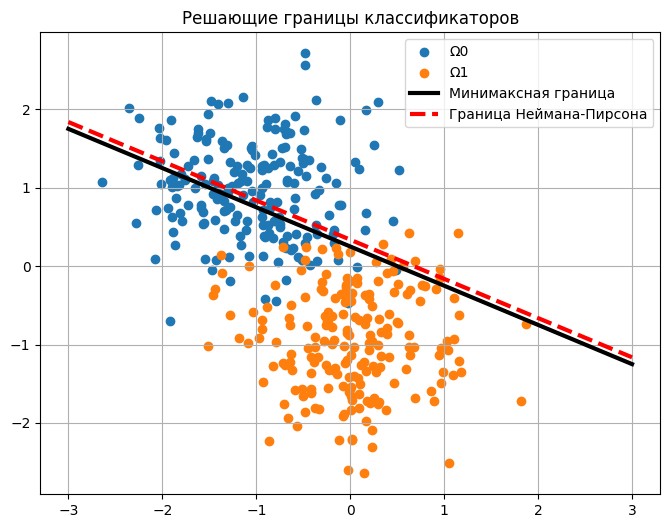

In [6]:
x = np.linspace(-3,3,200)

y_minimax = -(w[0]*x + w0)/w[1]

p0 = 0.05
m0 = w @ M0
sigma0 = np.sqrt(w @ B @ w)
gamma = m0 + sigma0*norm.ppf(1 - p0)
y_np = -(w[0]*x - gamma)/w[1]

plt.figure(figsize=(8,6))

plt.scatter(X0[:,0], X0[:,1], label="Ω0")
plt.scatter(X1[:,0], X1[:,1], label="Ω1")

plt.plot(x, y_minimax, 'k', linewidth=3, label="Минимаксная граница")
plt.plot(x, y_np, 'r--', linewidth=3, label="Граница Неймана-Пирсона")

plt.legend()
plt.grid()
plt.title("Решающие границы классификаторов")

plt.show()

# Байесовская разделяющая граница для двумерных нормальных векторов (Разные ковариации)


$$
d_l(x) = \frac{1}{2} x^T (B_j^{-1} - B_l^{-1}) x + (\overline{M}_l^T B_l^{-1} - \overline{M}_j^T B_j^{-1}) x + \frac{1}{2} \overline{M}_j^T B_j^{-1} \overline{M}_j - \frac{1}{2} \overline{M}_l^T B_l^{-1} \overline{M}_l + \frac{1}{2} \ln \frac{|B_j|}{|B_l|} + \ln \frac{P(\Omega_j)}{P(\Omega_l)} = 0 \quad (\forall j \neq l \Rightarrow \overline{x} \in D_l)

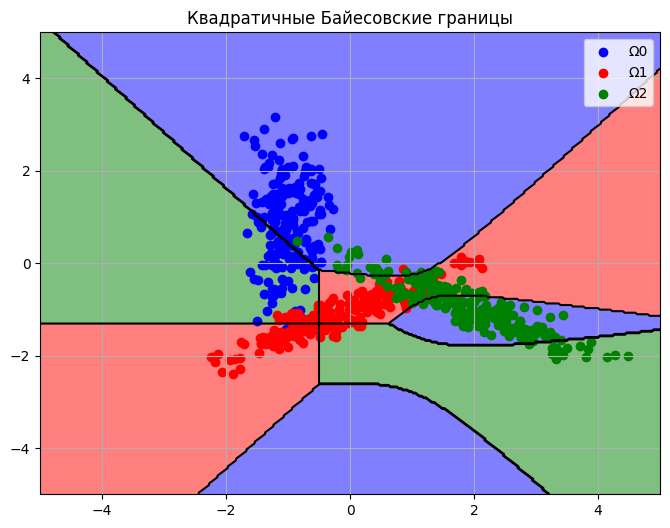

Экспериментальная ошибка для Ω0: 0.32
Экспериментальная ошибка для Ω1: 0.17
Экспериментальная ошибка для Ω2: 0.925
Суммарная вероятность ошибки: 0.4716666666666667

Относительная погрешность: 0.07483786951658176
Необходимый объем выборки: 448


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


def discriminant_qda(x, M_l, B_l, M_j, B_j, P_l=1, P_j=1):
    x = np.asarray(x)
    M_l = np.asarray(M_l)
    M_j = np.asarray(M_j)
    B_l = np.asarray(B_l)
    B_j = np.asarray(B_j)
    
    invB_l = np.linalg.inv(B_l)
    invB_j = np.linalg.inv(B_j)
    detB_l = np.linalg.det(B_l)
    detB_j = np.linalg.det(B_j)
    
    quad = 0.5 * x.T @ (invB_j - invB_l) @ x
    lin = (M_l.T @ invB_l - M_j.T @ invB_j) @ x
    const = 0.5 * (M_j.T @ invB_j @ M_j - M_l.T @ invB_l @ M_l) + 0.5 * np.log(detB_j/detB_l) + np.log(P_j/P_l)
    
    return quad + lin + const


def classify_qda(x, M_list, B_list):
    scores = []
    L = len(M_list)
    for l in range(L):
        score = 0
        for j in range(L):
            if j != l:
                score += discriminant_qda(x, M_list[l], B_list[l], M_list[j], B_list[j])
        scores.append(score)
    return np.argmax(scores)


def build_decision_regions_qda(M_list, B_list, grid_size=300):
    x = np.linspace(-5, 5, grid_size)
    y = np.linspace(-5, 5, grid_size)
    xx, yy = np.meshgrid(x, y)
    Z = np.zeros(xx.shape)
    
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            point = np.array([xx[i,j], yy[i,j]])
            Z[i,j] = classify_qda(point, M_list, B_list)
    return xx, yy, Z


def experimental_error(X, true_class, M_list, B_list):
    N = len(X)
    errors = 0
    for x in X:
        pred = classify_qda(x, M_list, B_list)
        if pred != true_class:
            errors += 1
    return errors / N

def required_sample_size(p):
    return (1 - p) / (0.0025 * p)

def relative_error(p, N):
    return np.sqrt( (1-p) / (N*p))


X0 = np.load("./../lab_1/distrib_uneq_1_[-1,1].npy")
X1 = np.load("./../lab_1/distrib_uneq_2_[0,-1].npy")
X2 = np.load("./../lab_1/distrib_uneq_3_[2,-1].npy")


M0 = np.array([1.0, 1.0])
B0 = np.array([[0.1, 0],
               [0, 0.9]])

M1 = np.array([0.0, -1.0])
B1 = np.array([[1, 0.5],
               [0.5, 0.3]])

M2 = np.array([-1.0, -1.0])
B2 = np.array([[1, -0.5],
               [-0.5, 0.3]])

M_list = [M0, M1, M2]
B_list = [B0, B1, B2]

xx, yy, Z = build_decision_regions_qda(M_list, B_list)

plt.figure(figsize=(8,6))
cmap = ListedColormap(['blue', 'red', 'green'])

plt.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5,2.5], cmap=cmap, alpha=0.5)
plt.contour(xx, yy, Z, levels=[0.5,1.5], colors='black')

plt.scatter(X0[:,0], X0[:,1], color='blue', label='Ω0')
plt.scatter(X1[:,0], X1[:,1], color='red', label='Ω1')
plt.scatter(X2[:,0], X2[:,1], color='green', label='Ω2')

plt.legend()
plt.grid()
plt.title("Квадратичные Байесовские границы")
plt.show()


p0 = experimental_error(X0, 0, M_list, B_list)
p1 = experimental_error(X1, 1, M_list, B_list)
p2 = experimental_error(X2, 2, M_list, B_list)

print("Экспериментальная ошибка для Ω0:", p0)
print("Экспериментальная ошибка для Ω1:", p1)
print("Экспериментальная ошибка для Ω2:", p2)


Pe = (p0 + p1 + p2)/3
print("Суммарная вероятность ошибки:", Pe)

N = len(X0)
eps = relative_error(Pe, N)
print(f"\nОтносительная погрешность: {eps}")


N_required = required_sample_size(Pe)
print("Необходимый объем выборки:", int(N_required))

# Байесовская разделяющая граница для двумерных бинарных векторов 
(в терминах отношения правдоподобия)

$$
w^{i}_{01} = \ln \frac{P(X_i = 1 \mid \Omega_0)\,(1 - P(X_i = 1 \mid \Omega_1))}
{P(X_i = 1 \mid \Omega_1)\,(1 - P(X_i = 1 \mid \Omega_0))}
$$

$$
w^{i}_{10} = \ln \frac{P(X_i = 0 \mid \Omega_1)\,(1 - P(X_i = 0 \mid \Omega_0))}
{P(X_i = 0 \mid \Omega_0)\,(1 - P(X_i = 0 \mid \Omega_1))}
$$

---

### Порог принятия решения 
$$
\lambda^{}_{01} = \ln \frac{P(\Omega_0)}{P(\Omega_1)} + \sum_{i=1}^{N} \ln \frac{1 - P(X_i = 1 \mid \Omega_0)}{1 - P(X_i = 1 \mid \Omega_1)}
$$

$$
\lambda^{}_{10} = \ln \frac{P(\Omega_1)}{P(\Omega_0)} + \sum_{i=1}^{N} \ln \frac{1 - P(X_i = 1 \mid \Omega_1)}{1 - P(X_i = 1 \mid \Omega_0)}
$$



---

### Решающее правило 

$$
\sum_{i=1}^{N} w^{i}_{01} x_i \ge \lambda^{}_{10}  \Rightarrow \overline{x} \in D_0
$$

$$
\sum_{i=1}^{N} w^{i}_{10} x_i \ge \lambda^{}_{01} \Rightarrow \overline{x} \in D_1
$$

---



--- Экспериментальные оценки ---
P(1|0) = 0.005
P(0|1) = 0.005
Суммарная вероятность ошибки = 0.005

--- Аналитические оценки ---
P(1|0) аналитическая = 0.0019163844429174182
P(0|1) аналитическая = 0.0020023303449237494
Суммарная аналитическая ошибка = 0.0019593573939205838


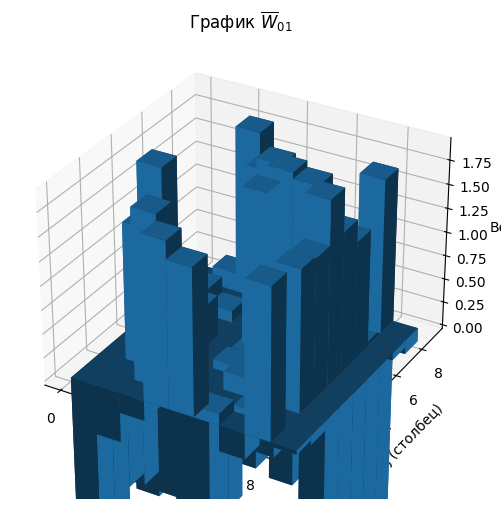

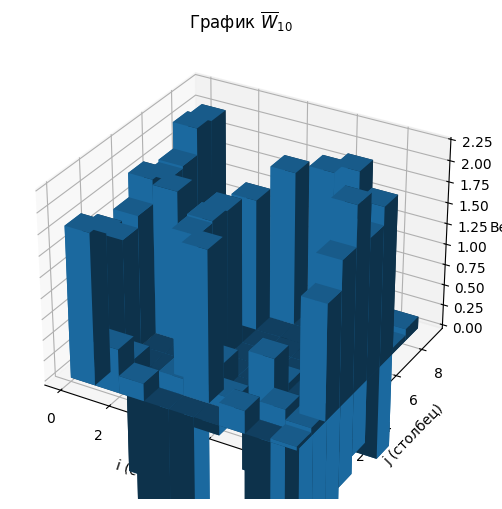

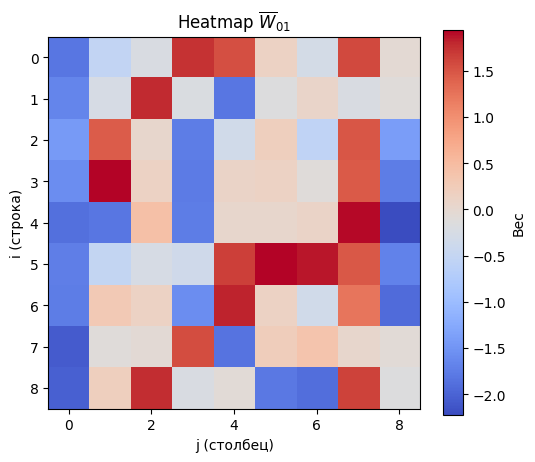

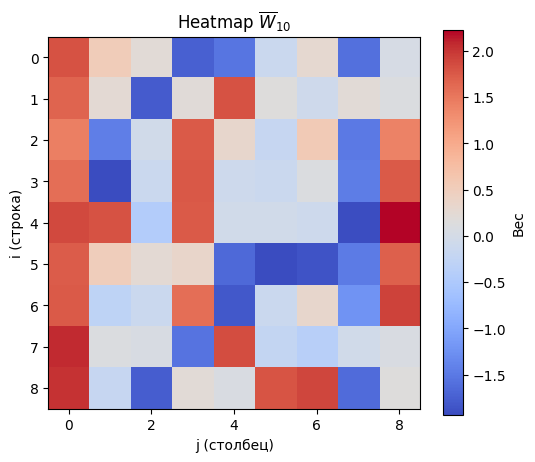

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm

def discriminant(x, W):
    return np.sum(W * x)


def classify(X, W10, lambda_01):
    labels = []
    for x in X:
        s10 = np.sum(W10 * x)

        if s10 >= lambda_01:
            labels.append(1)
        else:
            labels.append(0)

    return np.array(labels)


def plot_weights_3d(W, title):
    W_matrix = W.reshape(9,9) 
    x = np.arange(W_matrix.shape[0])
    y = np.arange(W_matrix.shape[1])
    X, Y = np.meshgrid(x, y)
    Z = W_matrix

    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')

    x_flat = X.ravel()
    y_flat = Y.ravel()
    z_flat = np.zeros_like(Z.ravel())
    dx = dy = 1.0
    dz = Z.ravel()

    ax.bar3d(x_flat, y_flat, z_flat, dx, dy, dz, shade=True)
    ax.set_xlabel('i (строка)')
    ax.set_ylabel('j (столбец)')
    ax.set_zlabel('Вес')
    ax.set_title(title)
    plt.show()

def plot_weights_heatmap(W, title):
    W_matrix = W.reshape(9,9)

    plt.figure(figsize=(6,5))
    plt.imshow(W_matrix, cmap='coolwarm', interpolation='nearest')
    plt.colorbar(label='Вес')
    
    plt.title(title)
    plt.xlabel('j (столбец)')
    plt.ylabel('i (строка)')
    
    plt.grid(False)
    plt.show()

X0 = np.load("sample_ya.npy") 
X1 = np.load("sample_yu.npy")

X0_vec = X0.reshape(X0.shape[0], -1)
X1_vec = X1.reshape(X1.shape[0], -1)

N_features = X0_vec.shape[1]  

P0 = 1
P1 = 1

epsilon = 1e-6
PX0 = (np.sum(X0_vec, axis=0) + epsilon) / (X0_vec.shape[0] + epsilon)
PX1 = (np.sum(X1_vec, axis=0) + epsilon) / (X1_vec.shape[0] + epsilon)

W10 = np.log(PX1 * (1-PX0) / (PX0 * (1-PX1)))
W01 = np.log(PX0 * (1-PX1) / (PX1 * (1-PX0)))

lambda_10 = np.log(P1/P0) + np.sum(np.log((1-PX1)/(1-PX0)))
lambda_01 = np.log(P0/P1) + np.sum(np.log((1-PX0)/(1-PX1)))

y0_pred = classify(X0_vec, W10, lambda_01)
y1_pred = classify(X1_vec, W10, lambda_01)

p0 = np.mean(y0_pred != 0)
p1 = np.mean(y1_pred != 1)
Pe = 0.5 * (p0 + p1)

print("\n--- Экспериментальные оценки ---")
print("P(1|0) =", p0)
print("P(0|1) =", p1)
print("Суммарная вероятность ошибки =", Pe)

m0 = np.sum(W10 * PX0)
m1 = np.sum(W10 * PX1)

sigma0 = np.sqrt(np.sum((W10**2) * PX0 * (1 - PX0)))
sigma1 = np.sqrt(np.sum((W10**2) * PX1 * (1 - PX1)))


p0_analytical = 1 - norm.cdf((lambda_01 - m0) / sigma0)
p1_analytical = norm.cdf((lambda_01 - m1) / sigma1)

Pe_analytical = 0.5 * (p0_analytical + p1_analytical)

print("\n--- Аналитические оценки ---")
print("P(1|0) аналитическая =", p0_analytical)
print("P(0|1) аналитическая =", p1_analytical)
print("Суммарная аналитическая ошибка =", Pe_analytical)


plot_weights_3d(W01, r'График $\overline{W}_{01}$')
plot_weights_3d(W10, r'График $\overline{W}_{10}$')

plot_weights_heatmap(W01, r'Heatmap $\overline{W}_{01}$')
plot_weights_heatmap(W10, r'Heatmap $\overline{W}_{10}$')